In [1]:
# =====================================================
# CELL 1: SETUP & IMPORTS
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Darts
from darts import TimeSeries, metrics
from darts.models import SKLearnClassifierModel, XGBClassifierModel
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

# Scikit-learn classifier
from sklearn.ensemble import RandomForestClassifier

# SHAP
import shap

# Classification metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

COLORS = {
    'IHSG': '#2E7D32', 'IHSG_light': '#4CAF50',
    'M2_YoY': '#1976D2', 'USDIDR': '#7B1FA2',
    'BI_Rate': '#F57C00', 'NPL_Ratio': '#C2185B',
    'up': '#2E7D32', 'down': '#D32F2F',
    'train': '#2E7D32', 'actual': '#1976D2', 'predicted': '#D32F2F',
}

print("✅ All imports successful")

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


✅ All imports successful


In [2]:
# =====================================================
# CELL 2: DATA LOADING & PREPROCESSING
# =====================================================
print("\n" + "=" * 70)
print("CELL 2: DATA LOADING & PREPROCESSING")
print("=" * 70)

df = pd.read_csv('dataset\\model1-new.csv')
df_clean = df.copy()

# Parse dates & force month-end
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y') + pd.offsets.MonthEnd(0)

# Convert percentage strings
pct_columns = ['BI Interest Rate', 'npl_ratio']
for col in pct_columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace('%', '').astype(float)

# Sort chronologically
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

# Rename columns
df_clean.columns = ['Date', 'IHSG', 'Inflation_YoY', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio', 'M2_MoM']

# Select variables (drop Inflation, keep M2_YoY)
df_model = df_clean[['Date', 'IHSG', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].copy()

# Create target: IHSG direction (1 = naik, 0 = turun)
df_model['IHSG_Return'] = df_model['IHSG'].pct_change() * 100
df_model['IHSG_Direction'] = (df_model['IHSG_Return'] > 0).astype(int)

# Drop first row (NaN from pct_change)
df_model = df_model.dropna().reset_index(drop=True)

print(f"Date Range: {df_model['Date'].min()} to {df_model['Date'].max()}")
print(f"Total Months: {len(df_model)}")
print(f"\nTarget Distribution:")
print(f"  Naik (1): {df_model['IHSG_Direction'].sum()} ({df_model['IHSG_Direction'].mean()*100:.1f}%)")
print(f"  Turun (0): {(1-df_model['IHSG_Direction']).sum()} ({(1-df_model['IHSG_Direction'].mean())*100:.1f}%)")
print(f"\nVariables: M2_YoY, USDIDR, BI_Rate, NPL_Ratio")
print(f"\nFirst 10 rows:")
print(df_model[['Date', 'IHSG', 'IHSG_Return', 'IHSG_Direction']].head(10).to_string(index=False))



CELL 2: DATA LOADING & PREPROCESSING
Date Range: 2015-01-31 00:00:00 to 2025-01-31 00:00:00
Total Months: 121

Target Distribution:
  Naik (1): 71 (58.7%)
  Turun (0): 50 (41.3%)

Variables: M2_YoY, USDIDR, BI_Rate, NPL_Ratio

First 10 rows:
      Date     IHSG  IHSG_Return  IHSG_Direction
2015-01-31 5289.404     1.194846               1
2015-02-28 5450.294     3.041742               1
2015-03-31 5518.675     1.254630               1
2015-04-30 5086.425    -7.832496               0
2015-05-31 5216.379     2.554918               1
2015-06-30 4910.658    -5.860790               0
2015-07-31 4802.529    -2.201925               0
2015-08-31 4509.607    -6.099328               0
2015-09-30 4223.908    -6.335341               0
2015-10-31 4455.180     5.475309               1



CELL 3: DESCRIPTIVE STATISTICS & EDA

--- IHSG Return by Direction ---
  Naik: mean=2.54%, std=1.97%, min=0.06%, max=9.44%
  Turun: mean=-2.82%, std=3.08%, min=-16.76%, max=-0.05%

--- Correlation with IHSG Direction ---
  M2_YoY         : +0.1431
  USDIDR         : -0.1740
  BI_Rate        : -0.1164
  NPL_Ratio      : +0.1548


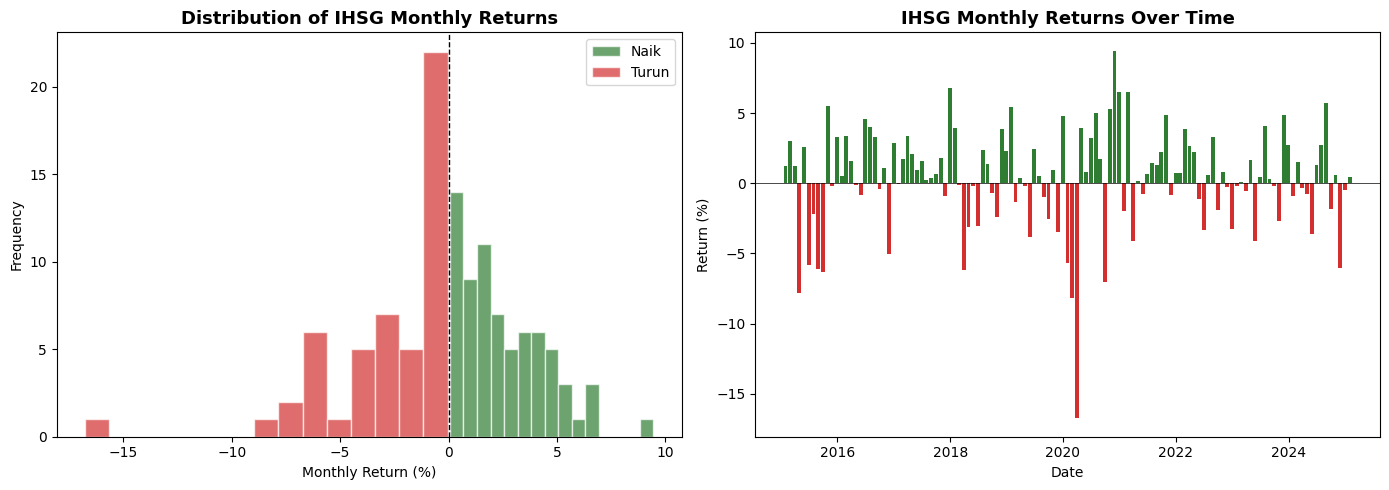

✅ Saved: classification_eda.png


In [3]:
# =====================================================
# CELL 3: DESCRIPTIVE STATISTICS & EDA
# =====================================================
print("\n" + "=" * 70)
print("CELL 3: DESCRIPTIVE STATISTICS & EDA")
print("=" * 70)

# Return statistics by direction
print("\n--- IHSG Return by Direction ---")
for direction in [1, 0]:
    subset = df_model[df_model['IHSG_Direction'] == direction]['IHSG_Return']
    label = "Naik" if direction == 1 else "Turun"
    print(f"  {label}: mean={subset.mean():.2f}%, std={subset.std():.2f}%, "
          f"min={subset.min():.2f}%, max={subset.max():.2f}%")

# Correlation of covariates with direction
print("\n--- Correlation with IHSG Direction ---")
for col in ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']:
    corr = df_model[col].corr(df_model['IHSG_Direction'])
    print(f"  {col:15s}: {corr:+.4f}")

# Plot: Return distribution by direction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return histogram
axes[0].hist(df_model[df_model['IHSG_Direction']==1]['IHSG_Return'], bins=15, 
             alpha=0.7, color=COLORS['up'], label='Naik', edgecolor='white')
axes[0].hist(df_model[df_model['IHSG_Direction']==0]['IHSG_Return'], bins=15, 
             alpha=0.7, color=COLORS['down'], label='Turun', edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of IHSG Monthly Returns', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Direction over time
colors_ts = [COLORS['up'] if d == 1 else COLORS['down'] for d in df_model['IHSG_Direction']]
axes[1].bar(df_model['Date'], df_model['IHSG_Return'], color=colors_ts, width=25)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('IHSG Monthly Returns Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('classification_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_eda.png")


In [4]:
# =====================================================
# CELL 4: CREATE DARTS TIMESERIES
# =====================================================
print("\n" + "=" * 70)
print("CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT")
print("=" * 70)

# Target: IHSG Direction (0/1)
target_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', value_cols='IHSG_Direction', freq='ME'
)

# Covariates (past covariates — known only up to current time)
covar_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', value_cols=['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio'], freq='ME'
)

# Train/Test Split 80:20
split_point = int(len(target_series) * 0.8)
target_train = target_series[:split_point]
target_test = target_series[split_point:]

covar_train = covar_series[:split_point]
covar_test = covar_series[split_point:]

# Scale covariates only (target is binary, no scaling needed)
scaler_covar = Scaler(MinMaxScaler(feature_range=(-1, 1)))
covar_train_scaled = scaler_covar.fit_transform(covar_train)
covar_test_scaled = scaler_covar.transform(covar_test)
covar_full_scaled = covar_train_scaled.append(covar_test_scaled)

print(f"Train: {target_train.start_time()} → {target_train.end_time()} ({len(target_train)} obs)")
print(f"Test:  {target_test.start_time()} → {target_test.end_time()} ({len(target_test)} obs)")
print(f"\nTrain target distribution:")
train_vals = target_train.values().flatten()
print(f"  Naik: {int(train_vals.sum())} ({train_vals.mean()*100:.1f}%)")
print(f"  Turun: {int(len(train_vals) - train_vals.sum())} ({(1-train_vals.mean())*100:.1f}%)")
print(f"\nTest target distribution:")
test_vals = target_test.values().flatten()
print(f"  Naik: {int(test_vals.sum())} ({test_vals.mean()*100:.1f}%)")
print(f"  Turun: {int(len(test_vals) - test_vals.sum())} ({(1-test_vals.mean())*100:.1f}%)")
print(f"\n✓ Covariates scaled (fit on train only)")



CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT
Train: 2015-01-31 00:00:00 → 2022-12-31 00:00:00 (96 obs)
Test:  2023-01-31 00:00:00 → 2025-01-31 00:00:00 (25 obs)

Train target distribution:
  Naik: 58 (60.4%)
  Turun: 38 (39.6%)

Test target distribution:
  Naik: 13 (52.0%)
  Turun: 12 (48.0%)

✓ Covariates scaled (fit on train only)


In [ ]:
# =====================================================
# CELL 5: RANDOM FOREST CLASSIFIER — GRIDSEARCH
# =====================================================
print("\n" + "=" * 70)
print("CELL 5: RANDOM FOREST CLASSIFIER")
print("=" * 70)

# Define parameter grid
param_grid_rf = {
    'lags': [1, 3, 6, 12],
    'lags_past_covariates': [1, 3, 6, 12],
    'output_chunk_length': [1],
}

# RF-specific params passed via model keyword
rf_model_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Since SKLearnClassifierModel doesn't support direct gridsearch on sklearn params,
# we do manual grid search
from itertools import product

print("Running manual GridSearch for RF Classifier...")

best_rf_accuracy = 0
best_rf_params = None
best_rf_model = None
total_tried = 0

# Grid for Darts lags
lags_options = [1, 3, 6, 12]
lags_covar_options = [1, 3, 6, 12]

# Grid for RF params
rf_configs = [
    {'n_estimators': 50, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 4},
    {'n_estimators': 200, 'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 4},
    {'n_estimators': 100, 'max_depth': 7, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 4},
    {'n_estimators': 200, 'max_depth': 7, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 4},
    {'n_estimators': 200, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 3, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 4},
    {'n_estimators': 300, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 4},
    {'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'min_samples_leaf': 2},
    
]

total_combos = len(lags_options) * len(lags_covar_options) * len(rf_configs)
print(f"Total combinations: {total_combos}")

for lags in lags_options:
    for lags_cov in lags_covar_options:
        for rf_cfg in rf_configs:
            try:
                total_tried += 1
                
                rf_sklearn = RandomForestClassifier(
                    random_state=42, n_jobs=-1, **rf_cfg
                )
                
                model = SKLearnClassifierModel(
                    model=rf_sklearn,
                    lags=lags,
                    lags_past_covariates=lags_cov,
                    output_chunk_length=1,
                )
                
                model.fit(
                    series=target_train,
                    past_covariates=covar_full_scaled,
                )
                
                # Predict on test using historical_forecasts
                preds = model.historical_forecasts(
                    series=target_series,
                    past_covariates=covar_full_scaled,
                    start=target_test.start_time(),
                    forecast_horizon=1,
                    stride=1,
                    retrain=False,
                    last_points_only=True,
                )
                
                # Calculate accuracy
                pred_vals = preds.values().flatten()
                actual_vals = target_test.values().flatten()[:len(pred_vals)]
                acc = accuracy_score(actual_vals, pred_vals)
                
                if acc > best_rf_accuracy:
                    best_rf_accuracy = acc
                    best_rf_params = {'lags': lags, 'lags_past_covariates': lags_cov, **rf_cfg}
                    best_rf_model = model
                    best_rf_preds = preds
                
                if total_tried % 30 == 0:
                    print(f"  Progress: {total_tried}/{total_combos} | Best accuracy so far: {best_rf_accuracy:.4f}")
                    
            except Exception as e:
                continue

print(f"\n✅ GridSearch complete ({total_tried} combinations tried)")
print(f"\nBest RF Accuracy: {best_rf_accuracy:.4f}")
print(f"Best Parameters:")
for k, v in best_rf_params.items():
    print(f"  {k}: {v}")

# Save best params
with open('rf_classifier_best_params.json', 'w') as f:
    json.dump({k: str(v) for k, v in best_rf_params.items()}, f, indent=2)


This model will treat target `series` lagged values as numeric input features (and not categorical).



CELL 5: RANDOM FOREST CLASSIFIER
Running manual GridSearch for RF Classifier...
Total combinations: 135


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

  Progress: 30/135 | Best accuracy so far: 0.6000


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

...

  Progress: 90/135 | Best accuracy so far: 0.6400


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

  Progress: 120/135 | Best accuracy so far: 0.6400


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate


✅ GridSearch complete (135 combinations tried)

Best RF Accuracy: 0.6400
Best Parameters:
  lags: 3
  lags_past_covariates: 1
  n_estimators: 100
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  min_samples_leaf: 2


In [7]:
# =====================================================
# CELL 6: XGBOOST CLASSIFIER
# =====================================================
print("\n" + "=" * 70)
print("CELL 6: XGBOOST CLASSIFIER")
print("=" * 70)

best_xgb_accuracy = 0
best_xgb_params = None
best_xgb_model = None
total_tried_xgb = 0

xgb_configs = [
    {'lags': 1, 'lags_past_covariates': 1},
    {'lags': 1, 'lags_past_covariates': 3},
    {'lags': 1, 'lags_past_covariates': 6},
    {'lags': 3, 'lags_past_covariates': 1},
    {'lags': 3, 'lags_past_covariates': 3},
    {'lags': 3, 'lags_past_covariates': 6},
    {'lags': 6, 'lags_past_covariates': 1},
    {'lags': 6, 'lags_past_covariates': 3},
    {'lags': 6, 'lags_past_covariates': 6},
]

xgb_ml_configs = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05},
]

total_xgb_combos = len(xgb_configs) * len(xgb_ml_configs)
print(f"Total combinations: {total_xgb_combos}")
print("Running GridSearch for XGBoost Classifier...")

for lag_cfg in xgb_configs:
    for xgb_cfg in xgb_ml_configs:
        try:
            total_tried_xgb += 1
            
            model_xgb = XGBClassifierModel(
                lags=lag_cfg['lags'],
                lags_past_covariates=lag_cfg['lags_past_covariates'],
                output_chunk_length=1,
                random_state=42,
                n_jobs=-1,
                **xgb_cfg,
            )
            
            model_xgb.fit(
                series=target_train,
                past_covariates=covar_full_scaled,
            )
            
            preds_xgb = model_xgb.historical_forecasts(
                series=target_series,
                past_covariates=covar_full_scaled,
                start=target_test.start_time(),
                forecast_horizon=1,
                stride=1,
                retrain=False,
                last_points_only=True,
            )
            
            pred_vals_xgb = preds_xgb.values().flatten()
            actual_vals_xgb = target_test.values().flatten()[:len(pred_vals_xgb)]
            acc_xgb = accuracy_score(actual_vals_xgb, pred_vals_xgb)
            
            if acc_xgb > best_xgb_accuracy:
                best_xgb_accuracy = acc_xgb
                best_xgb_params = {**lag_cfg, **xgb_cfg}
                best_xgb_model = model_xgb
                best_xgb_preds = preds_xgb
            
            if total_tried_xgb % 20 == 0:
                print(f"  Progress: {total_tried_xgb}/{total_xgb_combos} | Best accuracy: {best_xgb_accuracy:.4f}")
                
        except Exception as e:
            continue

print(f"\n✅ GridSearch complete ({total_tried_xgb} combinations)")
print(f"\nBest XGBoost Accuracy: {best_xgb_accuracy:.4f}")
print(f"Best Parameters:")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")

with open('xgb_classifier_best_params.json', 'w') as f:
    json.dump({k: str(v) for k, v in best_xgb_params.items()}, f, indent=2)


This model will treat target `series` lagged values as numeric input features (and not categorical).



CELL 6: XGBOOST CLASSIFIER
Total combinations: 90
Running GridSearch for XGBoost Classifier...


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

  Progress: 20/90 | Best accuracy: 0.5200


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

...

  Progress: 60/90 | Best accuracy: 0.6800


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not cate

  Progress: 80/90 | Best accuracy: 0.6800


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).



✅ GridSearch complete (90 combinations)

Best XGBoost Accuracy: 0.8000
Best Parameters:
  lags: 6
  lags_past_covariates: 6
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1


In [8]:
# =====================================================
# CELL 7: MODEL EVALUATION & COMPARISON
# =====================================================
print("\n" + "=" * 70)
print("CELL 7: MODEL EVALUATION & COMPARISON")
print("=" * 70)

def evaluate_classifier(actual_series, pred_series, model_name):
    """Evaluate classification model with full metrics."""
    actual = actual_series.values().flatten()
    pred = pred_series.values().flatten()
    
    # Align lengths
    min_len = min(len(actual), len(pred))
    actual = actual[:min_len]
    pred = pred[:min_len]
    
    metrics_dict = {
        'Accuracy': accuracy_score(actual, pred),
        'Precision': precision_score(actual, pred, zero_division=0),
        'Recall': recall_score(actual, pred, zero_division=0),
        'F1_Score': f1_score(actual, pred, zero_division=0),
    }
    
    print(f"\n{'─' * 50}")
    print(f"  {model_name} — Classification Report")
    print(f"{'─' * 50}")
    print(f"  Accuracy:  {metrics_dict['Accuracy']:.4f} ({metrics_dict['Accuracy']*100:.1f}%)")
    print(f"  Precision: {metrics_dict['Precision']:.4f}")
    print(f"  Recall:    {metrics_dict['Recall']:.4f}")
    print(f"  F1-Score:  {metrics_dict['F1_Score']:.4f}")
    
    print(f"\n  Detailed Classification Report:")
    print(classification_report(actual, pred, target_names=['Turun (0)', 'Naik (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(actual, pred)
    print(f"  Confusion Matrix:")
    print(f"                  Pred Turun  Pred Naik")
    print(f"  Actual Turun    {cm[0][0]:>8d}    {cm[0][1]:>8d}")
    print(f"  Actual Naik     {cm[1][0]:>8d}    {cm[1][1]:>8d}")
    
    return metrics_dict, cm

# Evaluate RF
rf_metrics, rf_cm = evaluate_classifier(target_test, best_rf_preds, "Random Forest Classifier")

# Evaluate XGBoost
xgb_metrics, xgb_cm = evaluate_classifier(target_test, best_xgb_preds, "XGBoost Classifier")

# Comparison table
print(f"\n{'=' * 70}")
print("MODEL COMPARISON")
print(f"{'=' * 70}")
print(f"{'Metric':<15} {'Random Forest':>15} {'XGBoost':>15} {'Winner':>10}")
print(f"{'─' * 55}")
for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1_Score']:
    rf_val = rf_metrics[metric_name]
    xgb_val = xgb_metrics[metric_name]
    winner = 'RF' if rf_val > xgb_val else 'XGB' if xgb_val > rf_val else 'Tie'
    print(f"{metric_name:<15} {rf_val:>15.4f} {xgb_val:>15.4f} {winner:>10}")



CELL 7: MODEL EVALUATION & COMPARISON

──────────────────────────────────────────────────
  Random Forest Classifier — Classification Report
──────────────────────────────────────────────────
  Accuracy:  0.6400 (64.0%)
  Precision: 0.6429
  Recall:    0.6923
  F1-Score:  0.6667

  Detailed Classification Report:
              precision    recall  f1-score   support

   Turun (0)       0.64      0.58      0.61        12
    Naik (1)       0.64      0.69      0.67        13

    accuracy                           0.64        25
   macro avg       0.64      0.64      0.64        25
weighted avg       0.64      0.64      0.64        25

  Confusion Matrix:
                  Pred Turun  Pred Naik
  Actual Turun           7           5
  Actual Naik            4           9

──────────────────────────────────────────────────
  XGBoost Classifier — Classification Report
──────────────────────────────────────────────────
  Accuracy:  0.8000 (80.0%)
  Precision: 0.7857
  Recall:    0.8462
  F


CELL 8: VISUALIZATIONS


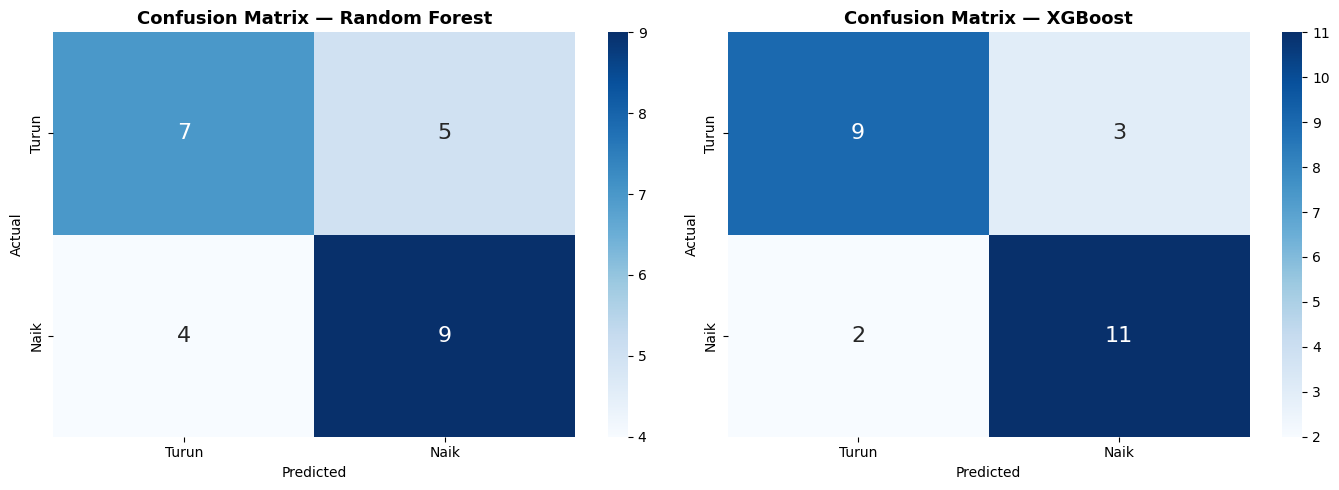

✅ Saved: classification_confusion_matrices.png


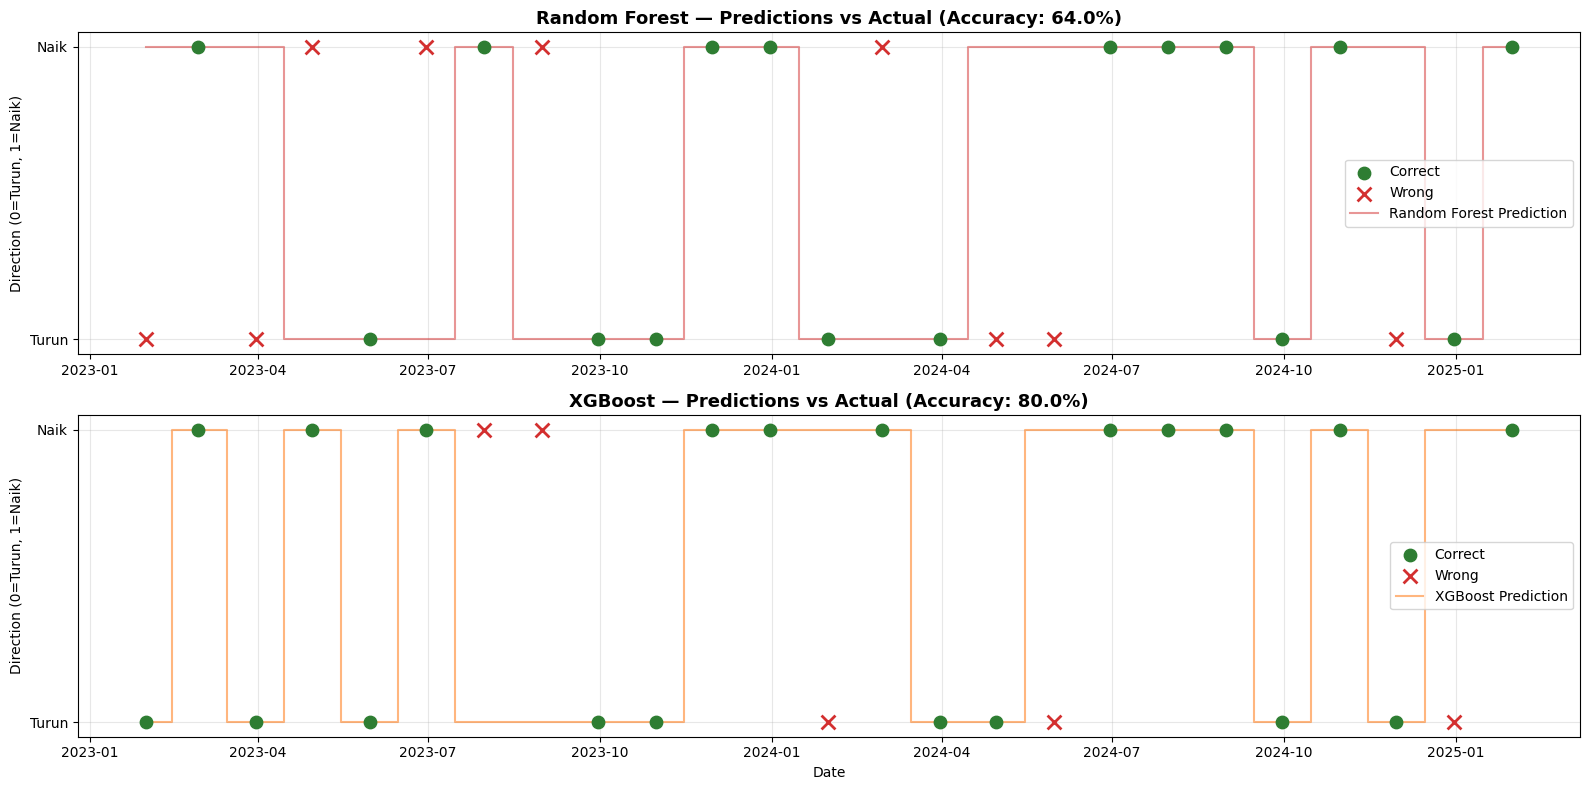

✅ Saved: classification_predictions_timeline.png


In [9]:
# =====================================================
# CELL 8: VISUALIZATION
# =====================================================
print("\n" + "=" * 70)
print("CELL 8: VISUALIZATIONS")
print("=" * 70)

# Plot 1: Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in [(axes[0], rf_cm, 'Random Forest'), (axes[1], xgb_cm, 'XGBoost')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Turun', 'Naik'], yticklabels=['Turun', 'Naik'],
                annot_kws={'size': 16})
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_confusion_matrices.png")

# Plot 2: Predictions over time
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

actual_vals_plot = target_test.values().flatten()
test_dates = target_test.time_index

for ax, preds, model_name, color in [
    (axes[0], best_rf_preds, 'Random Forest', COLORS['predicted']),
    (axes[1], best_xgb_preds, 'XGBoost', '#FF6F00')
]:
    pred_vals_plot = preds.values().flatten()
    min_len = min(len(actual_vals_plot), len(pred_vals_plot))
    dates = test_dates[:min_len]
    actual_plot = actual_vals_plot[:min_len]
    pred_plot = pred_vals_plot[:min_len]
    
    # Correct predictions
    correct = actual_plot == pred_plot
    
    ax.scatter(dates[correct], actual_plot[correct], color=COLORS['up'], 
               marker='o', s=80, label='Correct', zorder=3)
    ax.scatter(dates[~correct], actual_plot[~correct], color=COLORS['down'], 
               marker='x', s=100, linewidths=2, label='Wrong', zorder=3)
    ax.step(dates, pred_plot, where='mid', color=color, linewidth=1.5, 
            alpha=0.5, label=f'{model_name} Prediction')
    
    acc = accuracy_score(actual_plot, pred_plot)
    ax.set_title(f'{model_name} — Predictions vs Actual (Accuracy: {acc:.1%})', 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Direction (0=Turun, 1=Naik)')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Turun', 'Naik'])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('classification_predictions_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_predictions_timeline.png")


In [10]:
# =====================================================
# CELL 9: SHAP ANALYSIS (Random Forest)
# =====================================================
print("\n" + "=" * 70)
print("CELL 9: SHAP ANALYSIS")
print("=" * 70)

# Extract underlying sklearn model from best RF
try:
    # Access the underlying sklearn model
    # Darts SKLearnClassifierModel stores the model internally
    sklearn_model = best_rf_model.model
    
    # We need to recreate the feature matrix manually
    # Get the lagged features as the model sees them
    lags = best_rf_params['lags']
    lags_cov = best_rf_params['lags_past_covariates']
    
    # Build feature matrix from target lags + covariate lags
    target_vals = target_series.values().flatten()
    covar_vals = covar_full_scaled.values()  # (T, 4)
    covar_names = ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']
    
    # Create lagged feature matrix for test period
    feature_names = []
    features_list = []
    
    # Target lags
    for lag in range(1, lags + 1):
        feature_names.append(f'Direction_lag-{lag}')
    
    # Covariate lags
    for cov_name in covar_names:
        for lag in range(1, lags_cov + 1):
            feature_names.append(f'{cov_name}_lag-{lag}')
    
    # Build feature matrix for test period
    test_start_idx = split_point
    X_test = []
    
    for t in range(test_start_idx, len(target_vals)):
        row = []
        # Target lags
        for lag in range(1, lags + 1):
            if t - lag >= 0:
                row.append(target_vals[t - lag])
            else:
                row.append(0)
        # Covariate lags
        for c in range(covar_vals.shape[1]):
            for lag in range(1, lags_cov + 1):
                if t - lag >= 0:
                    row.append(covar_vals[t - lag, c])
                else:
                    row.append(0)
        X_test.append(row)
    
    X_test = np.array(X_test)
    
    # Also build training features for background
    X_train = []
    for t in range(max(lags, lags_cov), test_start_idx):
        row = []
        for lag in range(1, lags + 1):
            row.append(target_vals[t - lag])
        for c in range(covar_vals.shape[1]):
            for lag in range(1, lags_cov + 1):
                row.append(covar_vals[t - lag, c])
        X_train.append(row)
    X_train = np.array(X_train)
    
    print(f"Feature matrix shape (train): {X_train.shape}")
    print(f"Feature matrix shape (test): {X_test.shape}")
    print(f"Feature names: {feature_names}")
    
    # SHAP TreeExplainer
    explainer = shap.TreeExplainer(sklearn_model, X_train[:50])
    shap_values = explainer.shap_values(X_test)
    
    # For binary classification, shap_values might be a list [class_0, class_1]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # Class 1 (Naik)
    else:
        shap_vals = shap_values
    
    print(f"SHAP values shape: {shap_vals.shape}")
    
    # Mean absolute SHAP
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)
    
    print(f"\nFeature Importance (SHAP):")
    for _, row in shap_df.iterrows():
        print(f"  {row['Feature']:30s}: {row['Mean_Abs_SHAP']:.6f}")
    
    # Aggregate by category
    def get_category(feat):
        if 'Direction' in feat:
            return 'IHSG_Direction_Lags'
        elif 'M2_YoY' in feat:
            return 'M2_YoY'
        elif 'USDIDR' in feat:
            return 'USDIDR'
        elif 'BI_Rate' in feat:
            return 'BI_Rate'
        elif 'NPL' in feat:
            return 'NPL_Ratio'
        return 'Other'
    
    shap_df['Category'] = shap_df['Feature'].apply(get_category)
    cat_importance = shap_df.groupby('Category')['Mean_Abs_SHAP'].sum().sort_values(ascending=False)
    total_imp = cat_importance.sum()
    
    print(f"\nCategory Importance:")
    for cat, imp in cat_importance.items():
        print(f"  {cat:25s}: {imp:.6f} ({imp/total_imp*100:.1f}%)")
    
    # SHAP Plots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Bar plot
    shap_plot = shap_df.sort_values('Mean_Abs_SHAP', ascending=True)
    cat_colors = {
        'IHSG_Direction_Lags': COLORS['IHSG'], 'M2_YoY': COLORS['M2_YoY'],
        'USDIDR': COLORS['USDIDR'], 'BI_Rate': COLORS['BI_Rate'],
        'NPL_Ratio': COLORS['NPL_Ratio'], 'Other': '#666666'
    }
    bar_colors = [cat_colors.get(get_category(f), '#666666') for f in shap_plot['Feature']]
    axes[0].barh(shap_plot['Feature'], shap_plot['Mean_Abs_SHAP'], color=bar_colors)
    axes[0].set_title('Feature Importance (SHAP) — RF Classifier', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP Value|')
    
    # Category plot
    cat_plot = cat_importance.sort_values(ascending=True)
    cat_bar_colors = [cat_colors.get(c, '#666666') for c in cat_plot.index]
    bars = axes[1].barh(cat_plot.index, cat_plot.values, color=cat_bar_colors)
    for i, (cat, val) in enumerate(cat_plot.items()):
        axes[1].text(val + total_imp * 0.01, i, f'{val/total_imp*100:.1f}%', va='center')
    axes[1].set_title('Category Importance — RF Classifier', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Aggregated Mean |SHAP Value|')
    
    plt.tight_layout()
    plt.savefig('classification_shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: classification_shap_importance.png")
    
    # SHAP Beeswarm plot
    fig, ax = plt.subplots(figsize=(12, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=feature_names, show=False)
    plt.title('SHAP Beeswarm Plot — RF Classifier', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('classification_shap_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: classification_shap_beeswarm.png")
    
    # Save SHAP data
    shap_df.to_csv('classification_shap_features.csv', index=False)
    cat_importance.to_csv('classification_shap_categories.csv')

except Exception as e:
    print(f"⚠️ SHAP analysis error: {e}")
    print("  Trying alternative SHAP approach...")
    
    # Fallback: retrain a standalone RF with manual features
    try:
        # Build manual feature matrix
        target_vals = df_model['IHSG_Direction'].values
        covar_df = df_model[['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']]
        
        # Use lags from best params
        lags = best_rf_params.get('lags', 3)
        lags_cov = best_rf_params.get('lags_past_covariates', 3)
        
        feature_names = []
        X_all = []
        y_all = []
        
        start_idx = max(lags, lags_cov)
        
        for t in range(start_idx, len(target_vals)):
            row = []
            # Target lags
            for lag in range(1, lags + 1):
                row.append(target_vals[t - lag])
                if t == start_idx:
                    feature_names.append(f'Direction_lag-{lag}')
            # Covariate lags  
            for col in ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']:
                for lag in range(1, lags_cov + 1):
                    row.append(covar_df[col].iloc[t - lag])
                    if t == start_idx:
                        feature_names.append(f'{col}_lag-{lag}')
            
            X_all.append(row)
            y_all.append(target_vals[t])
        
        X_all = np.array(X_all)
        y_all = np.array(y_all)
        
        # Split
        split_idx = split_point - start_idx
        X_train_manual = X_all[:split_idx]
        X_test_manual = X_all[split_idx:]
        y_train_manual = y_all[:split_idx]
        y_test_manual = y_all[split_idx:]
        
        # Train standalone RF
        rf_standalone = RandomForestClassifier(
            n_estimators=best_rf_params.get('n_estimators', 200),
            max_depth=best_rf_params.get('max_depth', 5),
            max_features=best_rf_params.get('max_features', 'sqrt'),
            random_state=42, n_jobs=-1
        )
        rf_standalone.fit(X_train_manual, y_train_manual)
        
        # SHAP
        explainer = shap.TreeExplainer(rf_standalone, X_train_manual[:50])
        shap_values = explainer.shap_values(X_test_manual)
        
        if isinstance(shap_values, list):
            shap_vals = shap_values[1]
        else:
            shap_vals = shap_values
        
        # Mean absolute SHAP
        mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
        shap_df = pd.DataFrame({
            'Feature': feature_names,
            'Mean_Abs_SHAP': mean_abs_shap
        }).sort_values('Mean_Abs_SHAP', ascending=False)
        
        print(f"\nFeature Importance (SHAP - Fallback):")
        for _, row in shap_df.iterrows():
            print(f"  {row['Feature']:30s}: {row['Mean_Abs_SHAP']:.6f}")
        
        # SHAP plots
        fig, ax = plt.subplots(figsize=(12, 6))
        shap.summary_plot(shap_vals, X_test_manual, feature_names=feature_names, show=False)
        plt.title('SHAP Beeswarm Plot — RF Classifier (Standalone)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('classification_shap_beeswarm.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Saved: classification_shap_beeswarm.png (fallback)")
        
    except Exception as e2:
        print(f"⚠️ Fallback SHAP also failed: {e2}")




CELL 9: SHAP ANALYSIS
Feature matrix shape (train): (93, 7)
Feature matrix shape (test): (25, 7)
Feature names: ['Direction_lag-1', 'Direction_lag-2', 'Direction_lag-3', 'M2_YoY_lag-1', 'USDIDR_lag-1', 'BI_Rate_lag-1', 'NPL_Ratio_lag-1']
SHAP values shape: (25, 7, 2)
⚠️ SHAP analysis error: Per-column arrays must each be 1-dimensional
  Trying alternative SHAP approach...
⚠️ Fallback SHAP also failed: Per-column arrays must each be 1-dimensional


In [11]:
# =====================================================
# CELL 10: SUMMARY
# =====================================================
print("\n" + "=" * 70)
print("SUMMARY: KLASIFIKASI ARAH IHSG")
print("=" * 70)

print(f"""
📊 DATA:
   • Periode: {df_model['Date'].min().strftime('%B %Y')} — {df_model['Date'].max().strftime('%B %Y')}
   • Total observasi: {len(df_model)} bulan
   • Train/Test: 80%/20%
   • Target: Arah IHSG (1=Naik, 0=Turun)
   • Distribusi target: Naik {df_model['IHSG_Direction'].mean()*100:.1f}% / Turun {(1-df_model['IHSG_Direction'].mean())*100:.1f}%

📈 COVARIATES:
   1. M2_YoY (Money Supply Growth)
   2. USDIDR (Exchange Rate)
   3. BI_Rate (Interest Rate)
   4. NPL_Ratio (Credit Risk)

🤖 MODEL COMPARISON:
   Random Forest:
     • Accuracy:  {rf_metrics['Accuracy']:.4f} ({rf_metrics['Accuracy']*100:.1f}%)
     • Precision: {rf_metrics['Precision']:.4f}
     • Recall:    {rf_metrics['Recall']:.4f}
     • F1-Score:  {rf_metrics['F1_Score']:.4f}
     • Params:    {best_rf_params}

   XGBoost:
     • Accuracy:  {xgb_metrics['Accuracy']:.4f} ({xgb_metrics['Accuracy']*100:.1f}%)
     • Precision: {xgb_metrics['Precision']:.4f}
     • Recall:    {xgb_metrics['Recall']:.4f}
     • F1-Score:  {xgb_metrics['F1_Score']:.4f}
     • Params:    {best_xgb_params}

🏆 BEST MODEL: {'Random Forest' if rf_metrics['F1_Score'] >= xgb_metrics['F1_Score'] else 'XGBoost'}
""")

print("Files generated:")
print("  - classification_eda.png")
print("  - classification_confusion_matrices.png")
print("  - classification_predictions_timeline.png")
print("  - classification_shap_importance.png")
print("  - classification_shap_beeswarm.png")
print("  - classification_shap_features.csv")
print("  - classification_shap_categories.csv")
print("  - rf_classifier_best_params.json")
print("  - xgb_classifier_best_params.json")

print(f"\n{'=' * 70}")
print("CLASSIFICATION MODEL COMPLETE!")
print(f"{'=' * 70}")


SUMMARY: KLASIFIKASI ARAH IHSG

📊 DATA:
   • Periode: January 2015 — January 2025
   • Total observasi: 121 bulan
   • Train/Test: 80%/20%
   • Target: Arah IHSG (1=Naik, 0=Turun)
   • Distribusi target: Naik 58.7% / Turun 41.3%

📈 COVARIATES:
   1. M2_YoY (Money Supply Growth)
   2. USDIDR (Exchange Rate)
   3. BI_Rate (Interest Rate)
   4. NPL_Ratio (Credit Risk)

🤖 MODEL COMPARISON:
   Random Forest:
     • Accuracy:  0.6400 (64.0%)
     • Precision: 0.6429
     • Recall:    0.6923
     • F1-Score:  0.6667
     • Params:    {'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 2}

   XGBoost:
     • Accuracy:  0.8000 (80.0%)
     • Precision: 0.7857
     • Recall:    0.8462
     • F1-Score:  0.8148
     • Params:    {'lags': 6, 'lags_past_covariates': 6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

🏆 BEST MODEL: XGBoost

Files generated:
  - classification_eda.png
  - classif